## 1. Setup and Data Preparation

In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# --- 1. Silence Warnings and System Logs ---
# Specifically silence the NotOpenSSLWarning from urllib3
warnings.filterwarnings("ignore", category=UserWarning, module="urllib3")
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- 2. Data Loading & Utility Functions ---
def load_hmd_mx(filepath):
    df = pd.read_csv(filepath, skiprows=2, sep='\s+')
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    for col in ['Female', 'Male', 'Total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['Total'])

def create_sequences(data, window_size):
    """Create sliding window sequences for LSTM training."""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

# Load data and prepare log-mortality matrix
df = load_hmd_mx('../data/Mx_1x1.txt')
df_clean = df[(df['Year'] >= 1950) & (df['Age'] <= 95)].copy()
mx_matrix = df_clean.pivot(index='Age', columns='Year', values='Total').replace(0, 1e-8)
log_mx = np.log(mx_matrix)

# --- 3. Lee-Carter Parameter Extraction via SVD ---
alpha_x = log_mx.mean(axis=1)
Z = log_mx.sub(alpha_x, axis=0)
U, S, Vh = np.linalg.svd(Z, full_matrices=False)

# Extract bx (age sensitivity) and kt (time index)
# Standard normalization: sum(bx) = 1
bx = U[:, 0] / U[:, 0].sum()
kt = Vh[0, :] * S[0] * U[:, 0].sum()

# Ensure kt is decreasing over time (standard Lee-Carter convention)
if kt[0] < kt[-1]: 
    kt = -kt
    bx = -bx

# --- 4. Scaling and Sequence Preparation ---
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
kt_scaled = scaler_lstm.fit_transform(kt.reshape(-1, 1))

window_size = 10
X_all, y_all = create_sequences(kt_scaled, window_size)
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

print(f"Setup complete. Variables 'kt' and 'bx' defined.")
print(f"Data ready for MC Dropout. Window size: {window_size}")

Setup complete. Variables 'kt' and 'bx' defined.
Data ready for MC Dropout. Window size: 10


## 2. Monte Carlo Dropout Model Definition

In [7]:
# --- 2. Defining the Probabilistic LSTM Model ---
def build_mcd_lstm(input_shape):
    """
    Builds an LSTM model with Dropout layers.
    Dropout is necessary for Monte Carlo sampling.
    """
    model = Sequential([
        LSTM(64, activation='relu', input_shape=input_shape, return_sequences=False),
        Dropout(0.2), # Dropout rate defines the 'spread' of uncertainty
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def predict_with_mcd(model, X_input, n_iter=100):
    """
    Performs multiple forward passes with Dropout active (training=True).
    This generates a distribution of predictions rather than a single point.
    """
    predictions = []
    for _ in range(n_iter):
        # By setting training=True, we keep Dropout active during inference
        y_p = model(X_input, training=True)
        predictions.append(y_p.numpy())
    return np.array(predictions)

# Initializing model
model_mcd = build_mcd_lstm((window_size, 1))
print("MCD-LSTM architecture defined. Ready for stochastic training.")

MCD-LSTM architecture defined. Ready for stochastic training.


## 3. Training and Stochastic Forecasting (Monte Carlo Sampling)

In [8]:
# --- 1. Training the MCD Model ---
# We use more epochs to ensure the model learns a robust distribution
print("Training MCD-LSTM model...")
model_mcd.fit(X_all, y_all, epochs=200, batch_size=32, verbose=0)

# --- 2. Stochastic Projection (2025-2050) ---
n_future = 2050 - 2024
n_sims = 100 # Number of Monte Carlo passes
all_sims = []

print(f"Generating {n_sims} stochastic trajectories via MC Dropout...")

for s in range(n_sims):
    # Start from the last available window
    curr_batch = kt_scaled[-window_size:].reshape((1, window_size, 1))
    sim_path = []
    
    for _ in range(n_future):
        # training=True keeps Dropout active during prediction
        next_v = model_mcd(curr_batch, training=True).numpy()[0, 0]
        sim_path.append(next_v)
        
        # Update window
        next_v_reshaped = np.array(next_v).reshape(1, 1, 1)
        curr_batch = np.append(curr_batch[:, 1:, :], next_v_reshaped, axis=1)
    
    # Invert scaling
    sim_path_inv = scaler_lstm.inverse_transform(np.array(sim_path).reshape(-1, 1)).flatten()
    all_sims.append(sim_path_inv)
    
    if (s + 1) % 20 == 0:
        print(f" > Simulations completed: {s+1}/{n_sims}")

all_sims = np.array(all_sims)
print(f"\nStochastic projection complete. Shape: {all_sims.shape}")

Training MCD-LSTM model...
Generating 100 stochastic trajectories via MC Dropout...
 > Simulations completed: 20/100
 > Simulations completed: 40/100
 > Simulations completed: 60/100
 > Simulations completed: 80/100
 > Simulations completed: 100/100

Stochastic projection complete. Shape: (100, 26)


## 4. Visualizing the Neural Fan Chart

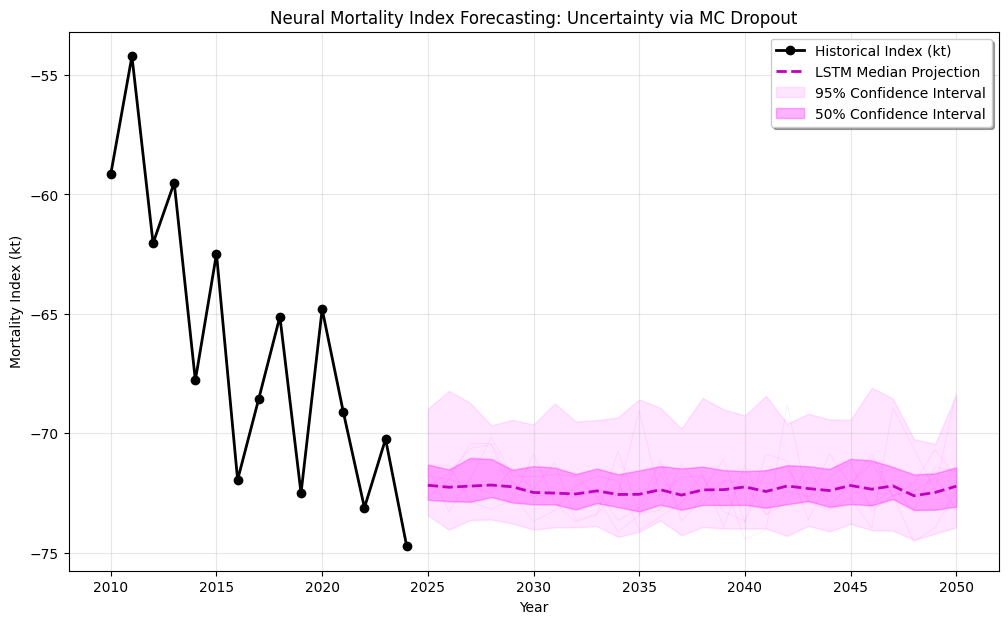

Fan Chart generated. The 95% uncertainty spread in 2050 is: 5.5435


In [9]:
# --- 1. Statistical Summary ---
future_years = np.arange(2025, 2051)
# Calculate percentiles for the uncertainty bands
median_proj = np.percentile(all_sims, 50, axis=0)
lower_95 = np.percentile(all_sims, 2.5, axis=0)
upper_95 = np.percentile(all_sims, 97.5, axis=0)
lower_50 = np.percentile(all_sims, 25, axis=0)
upper_50 = np.percentile(all_sims, 75, axis=0)

# --- 2. Visualization ---
plt.figure(figsize=(12, 7))

# Plot historical data (last 15 years for context)
plt.plot(np.arange(2010, 2025), kt[-15:], 'ko-', label='Historical Index (kt)', linewidth=2)

# Plot Median Projection
plt.plot(future_years, median_proj, 'm--', label='LSTM Median Projection', linewidth=2)

# Plot 95% Confidence Interval (Epistemic Uncertainty)
plt.fill_between(future_years, lower_95, upper_95, color='magenta', alpha=0.1, label='95% Confidence Interval')

# Plot 50% Confidence Interval (Interquartile Range)
plt.fill_between(future_years, lower_50, upper_50, color='magenta', alpha=0.3, label='50% Confidence Interval')

# Plot some individual trajectories to show the "stochastic nature"
for i in range(5):
    plt.plot(future_years, all_sims[i], color='magenta', alpha=0.1, linewidth=0.5)

plt.title('Neural Mortality Index Forecasting: Uncertainty via MC Dropout')
plt.xlabel('Year')
plt.ylabel('Mortality Index (kt)')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(alpha=0.3)

# Save the uncertainty plot
plt.savefig('../reports/figures/10_lstm_uncertainty_fan.png', dpi=300)
plt.show()

print(f"Fan Chart generated. The 95% uncertainty spread in 2050 is: {upper_95[-1] - lower_95[-1]:.4f}")

## 5. From Index to Survival Probability ($tP_x$)

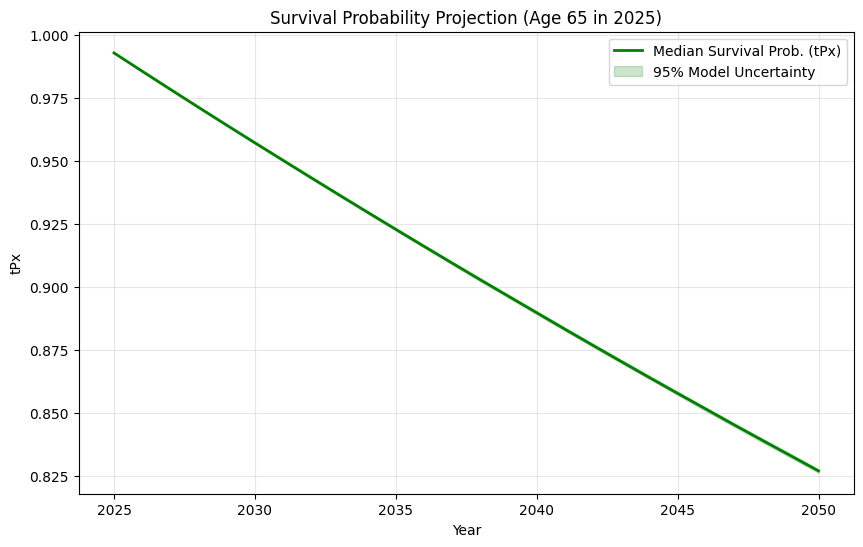

Analysis complete. The probability of a 65yo surviving to 2050 (age 90) is between 82.6% and 82.8%.


In [10]:
# --- 1. Mapping kt simulations back to Mortality Rates (mx) ---
# We use alpha_x and bx from the SVD performed in Cell 1
target_age = 65
future_years_count = len(future_years)

# Extract alpha and beta for the specific age
a_x = alpha_x[target_age]
b_x = bx[target_age]

# Transform all 100 simulations of kt into log(mx) paths
# log(mx) = alpha_x + bx * kt
log_mx_sims = a_x + (b_x * all_sims)
mx_sims = np.exp(log_mx_sims)

# --- 2. Calculate Survival Probability (tPx) ---
# tPx = exp(-sum(mx))
tpx_sims = np.exp(-np.cumsum(mx_sims, axis=1))

# --- 3. Plotting the Survival Uncertainty ---
plt.figure(figsize=(10, 6))
tpx_median = np.percentile(tpx_sims, 50, axis=0)
tpx_lower = np.percentile(tpx_sims, 2.5, axis=0)
tpx_upper = np.percentile(tpx_sims, 97.5, axis=0)

plt.plot(future_years, tpx_median, 'g-', label='Median Survival Prob. (tPx)', linewidth=2)
plt.fill_between(future_years, tpx_lower, tpx_upper, color='green', alpha=0.2, label='95% Model Uncertainty')

plt.title(f'Survival Probability Projection (Age {target_age} in 2025)')
plt.xlabel('Year')
plt.ylabel('tPx')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('../reports/figures/11_survival_uncertainty_65.png', dpi=300)
plt.show()

print(f"Analysis complete. The probability of a 65yo surviving to 2050 (age 90) is between {tpx_lower[-1]*100:.1f}% and {tpx_upper[-1]*100:.1f}%.")

## 6. Residual Analysis (Age-Year Heatmap)

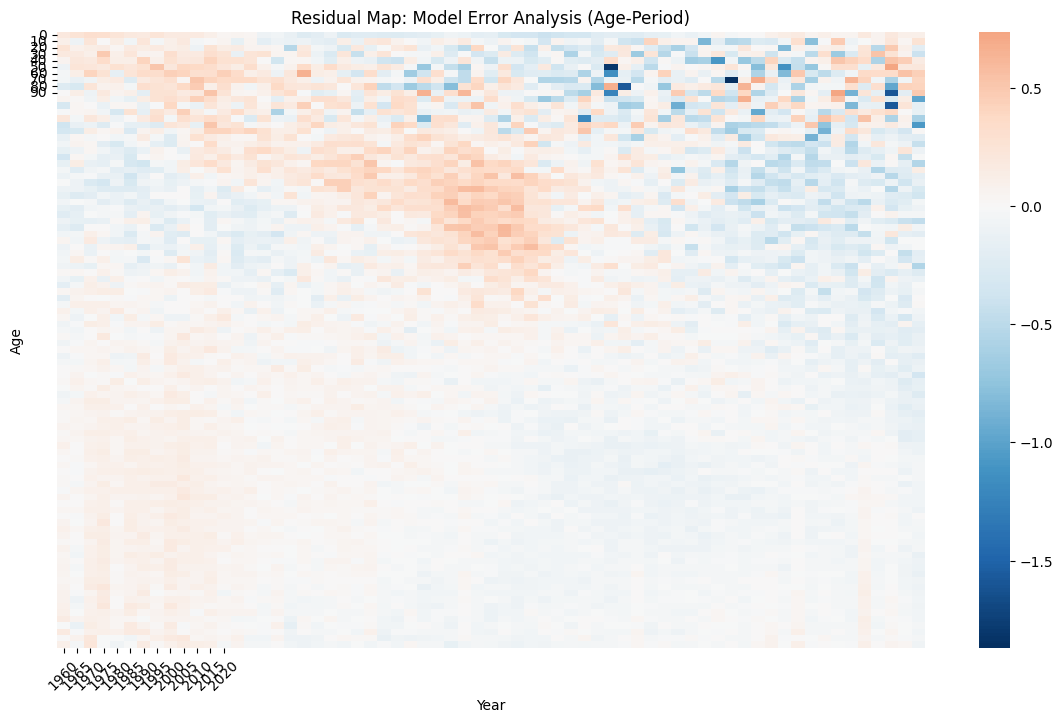

Heatmap analysis complete. Matrix shape: (96, 65)


In [13]:
import seaborn as sns

# --- 1. Reconstruct kt from the model ---
# Reconstruct kt for the sequences used in training
kt_reconstructed_scaled = model_mcd.predict(X_all, verbose=0)
kt_reconstructed = scaler_lstm.inverse_transform(kt_reconstructed_scaled).flatten()

# --- 2. Data Alignment (Forcing Numpy conversion) ---
# We convert everything to pure numpy arrays to avoid Pandas indexing issues
alpha_vec = alpha_x.to_numpy() if hasattr(alpha_x, 'to_numpy') else np.array(alpha_x)
bx_vec = bx.to_numpy() if hasattr(bx, 'to_numpy') else np.array(bx)

# Actual data alignment: we skip the first 'window_size' years
actual_log_mx_matrix = log_mx.iloc[:, window_size:].to_numpy()
years_labels = log_mx.columns[window_size:]
ages_labels = log_mx.index

# --- 3. Residual Calculation ---
# Predicted = alpha + (bx * kt)
# np.outer handles the cross product between age sensitivity and time index
term_structure = np.outer(bx_vec, kt_reconstructed)
pred_log_mx = alpha_vec[:, np.newaxis] + term_structure

# Residuals: Actual - Predicted
residuals = actual_log_mx_matrix - pred_log_mx

# --- 4. Plotting the Heatmap ---
plt.figure(figsize=(14, 8))
sns.heatmap(residuals, cmap='RdBu_r', center=0, 
            xticklabels=years_labels[::5], yticklabels=ages_labels[::10])

plt.title('Residual Map: Model Error Analysis (Age-Period)')
plt.xlabel('Year')
plt.ylabel('Age')
plt.xticks(rotation=45)

# Final save
plt.savefig('../reports/figures/12_residual_heatmap.png', dpi=300)
plt.show()

print(f"Heatmap analysis complete. Matrix shape: {residuals.shape}")